Zarzycki Psychological Readiness to Return to Sport Is Associated With Knee Kinematic Asymmetry During Gait Following Anterior Cruciate Ligament Reconstruction 02.csv has 79 items and we are trying 2 replacement(s) which means there are 3081 to iterate through.


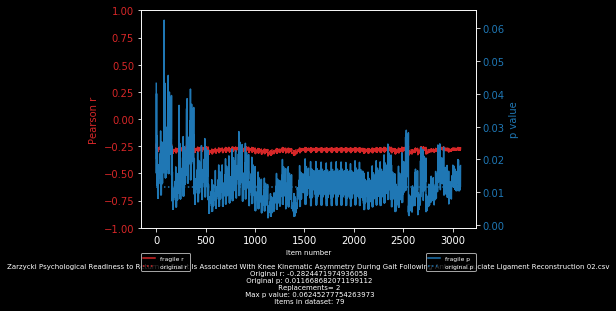

Maximum p value 0.06245277754263973 at item 81 which has an r of -0.21061069335346183 
Replacing 2 of the original values which were ((12.37, 10.93), (32.34, 14.92)) with (60.61, 4.43)


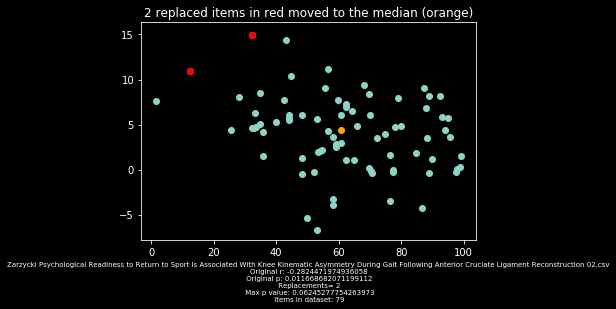

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import statistics
from scipy import stats
from tqdm.notebook import trange, tqdm
import math

# ── Configuration ─────────────────────────────────────────────────────────────
# Set the filename and number of replacements.
# The CSV must have exactly 2 columns (X and Y values).
# Headers are detected automatically – both headerless and headed files work.
filename = 'Arampantzis.csv'
n = 2

# ── Load data with automatic header detection ─────────────────────────────────
def _is_numeric(s: str) -> bool:
    try:
        float(s)
        return True
    except ValueError:
        return False

def load_two_column_csv(path: str):
    """
    Read a two-column CSV, auto-detecting whether a header row is present.
    Returns numpy arrays x and y.
    """
    raw = pd.read_csv(path, header=None, nrows=1)
    first_row = raw.iloc[0]
    has_header = any(not _is_numeric(str(val)) for val in first_row)
    df = pd.read_csv(path, header=0 if has_header else None)
    if df.shape[1] != 2:
        raise ValueError(f"Expected exactly 2 columns, got {df.shape[1]}.")
    df.columns = ['X', 'Y']
    df['X'] = pd.to_numeric(df['X'], errors='coerce')
    df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
    df = df.dropna()
    if has_header:
        print(f"Header row detected and skipped. Using numeric data rows only.")
    else:
        print(f"No header detected. Reading all rows as data.")
    return df['X'].to_numpy(), df['Y'].to_numpy()

x, y = load_two_column_csv(filename)
row_count = len(x)

r, p = stats.pearsonr(x, y)
print(f"{filename} has {row_count} items. Testing {n} replacement(s) → {math.comb(row_count, n):,} combination(s).")

# ── Run fragility analysis ────────────────────────────────────────────────────
appendtuple = (statistics.median(x), statistics.median(y))
data = list(zip(x, y))
replacement_candidates = list(itertools.combinations(data, n))

def diff_list(li1, li2):
    """Remove items in li2 from a copy of li1, preserving duplicates."""
    result = list(li1)
    for item in li2:
        result.remove(item)
    return result

p2values = []
r2values = []
for i in tqdm(range(len(replacement_candidates))):
    a = diff_list(data, replacement_candidates[i])
    for k in range(n):
        a.append(appendtuple)
    res_listx = [pt[0] for pt in a]
    res_listy = [pt[1] for pt in a]
    r2, p2 = stats.pearsonr(res_listx, res_listy)
    p2values.append(p2)
    r2values.append(r2)

# ── Line chart ────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel(
    f'Item number\n\n{filename}\nOriginal r: {r:.4f}\nOriginal p: {p:.4f}\n'
    f'Replacements = {n}\nMax p value: {max(p2values):.4f}\nItems in dataset: {row_count}',
    fontsize=7
)
ax1.set_ylabel('Pearson r', color=color)
ax1.set_ylim(-1, 1)
ax1.plot(range(len(r2values)), r2values, color=color, label='fragile r')
ax1.tick_params(axis='y', labelcolor=color)
ax1.hlines(r, 0, len(p2values), linestyles='dotted', label=f'original r = {r:.4f}', color='tab:red')
ax1.legend(fontsize=6, loc=(0, -0.22))

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('p value', color=color)
ax2.plot(range(len(p2values)), p2values, color=color, label='fragile p')
ax2.hlines(p, 0, len(p2values), linestyles='dotted', label=f'original p = {p:.4f}', color='tab:blue')
ax2.hlines(0.05, 0, len(p2values), linestyles='dashed', color='gray', linewidth=0.8, label='p = 0.05')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(fontsize=6, loc=(0.72, -0.28))

plt.savefig(f'{filename} output.pdf', bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
maxpos = p2values.index(max(p2values))
replaced_label = 'value' if n == 1 else 'values'
were_was = 'was' if n == 1 else 'were'
print(
    f"Maximum p value: {max(p2values):.4f} at combination {maxpos + 1}, "
    f"which has an r of {r2values[maxpos]:.4f}\n"
    f"Replacing {n} {replaced_label} which {were_was} {replacement_candidates[maxpos]} "
    f"with median {appendtuple}"
)

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots()
x_val = [pt[0] for pt in replacement_candidates[maxpos]]
y_val = [pt[1] for pt in replacement_candidates[maxpos]]
ax1.scatter(x, y, alpha=0.7, label='Original data')
ax1.scatter(x_val, y_val, color='red', zorder=5, label=f'Point{"s" if n > 1 else ""} to replace')
ax1.scatter(statistics.median(x), statistics.median(y), color='orange', marker='*', s=150, zorder=6, label='Median (replacement)')
ax1.set_xlabel(
    f'{filename}\nOriginal r: {r:.4f}\nOriginal p: {p:.4f}\n'
    f'Replacements = {n}\nMax p value: {max(p2values):.4f}\nItems in dataset: {row_count}',
    fontsize=7
)
ax1.legend(fontsize=8)
plt.title(f'{n} replaced item{"s" if n > 1 else ""} in red → moved to the median (orange)')
plt.savefig(f'{filename} new scatter.pdf', bbox_inches='tight')
plt.show()
